# 03 — Option Pricing

In this notebook we price **European call and put options** on the asset calibrated
in Notebook 02, using two complementary approaches:

1. **Analytical pricing** via the closed-form Black–Scholes formula
2. **Monte Carlo simulation** under the risk-neutral measure, with two variance
   reduction techniques to improve estimator efficiency

We also compute the **option Greeks** and study **implied volatility** as a function
of strike price.

## The Black–Scholes Formula

Under GBM with constant drift $\mu$ and volatility $\sigma$, and given a
risk-free rate $r$, the price of a European call option with strike $K$ and
expiry $T$ is:

$$
C = S_0\, N(d_1) - K e^{-rT} N(d_2)
$$

and the corresponding put price is:

$$
P = K e^{-rT} N(-d_2) - S_0\, N(-d_1)
$$

where

$$
d_1 = \frac{\ln(S_0/K) + \left(r + \tfrac{1}{2}\sigma^2\right)T}{\sigma\sqrt{T}},
\qquad
d_2 = d_1 - \sigma\sqrt{T}
$$

and $N(\cdot)$ is the standard normal CDF.

## Risk-Neutral Pricing

A key insight of Black–Scholes is that option prices do not depend on the
real-world drift $\mu$. Instead, we price under the **risk-neutral measure**
$\mathbb{Q}$, replacing $\mu$ with the risk-free rate $r$:

$$
S_T = S_0 \exp\!\left(\left(r - \tfrac{1}{2}\sigma^2\right)T + \sigma\sqrt{T}\,Z\right),
\quad Z \sim \mathcal{N}(0,1)
$$

The option price is then the **discounted expected payoff** under $\mathbb{Q}$:

$$
C = e^{-rT}\,\mathbb{E}^{\mathbb{Q}}\!\left[\max(S_T - K,\, 0)\right]
$$

## Variance Reduction

Plain Monte Carlo converges at rate $\mathcal{O}(n^{-1/2})$, which is slow.
We implement two techniques to reduce estimator variance without increasing
the number of paths:

- **Antithetic variates** — for every draw $Z$, also simulate $-Z$; the two
  payoffs are negatively correlated and their average has lower variance
- **Control variates** — exploit the known analytical result
  $\mathbb{E}^{\mathbb{Q}}[e^{-rT} S_T] = S_0$ to correct the MC estimate
  via OLS regression

In [1]:
# Import necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from scipy.stats import norm
import json
import warnings
warnings.filterwarnings("ignore")

# Consistent plot style across all notebooks
plt.rcParams.update({
    "figure.dpi": 110,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

In [2]:
# Load Parameters from Notebook 02 (GBM_Parameter_Estimation.ipynb)
# Load the GBM parameters estimated from real SPY data
with open("estimated_params.json", "r") as f:
    params = json.load(f)

ticker    = params["ticker"]
sigma     = params["sigma"]       # annualised volatility from MLE
mu        = params["mu"]          # annualised drift from MLE
S0        = params["s0"]          # last observed SPY price

# Option and market parameters
K         = round(S0)             # at-the-money strike (rounded to nearest dollar)
T         = 1.0                   # time to expiry in years
r_f       = 0.05                  # risk-free rate (annualised)
DT        = 1 / 252               # one trading day

print(f"Loaded parameters for {ticker}")
print(f"  S0    = {S0:.2f}")
print(f"  K     = {K:.2f}  (at-the-money strike)")
print(f"  σ     = {sigma:.4f}  ({sigma*100:.2f}% p.a.)")
print(f"  μ     = {mu:.4f}  ({mu*100:.2f}% p.a.)")
print(f"  r_f   = {r_f:.4f}  ({r_f*100:.2f}% p.a.)")
print(f"  T     = {T} year")

Loaded parameters for SPY
  S0    = 581.39
  K     = 581.00  (at-the-money strike)
  σ     = 0.1768  (17.68% p.a.)
  μ     = 0.1385  (13.85% p.a.)
  r_f   = 0.0500  (5.00% p.a.)
  T     = 1.0 year


In [3]:
# Black-Scholes Closed-Form Pricer
def black_scholes(S, K, T, r, sigma, option_type="call"):
    """
    Compute the Black-Scholes price for a European option.

    Parameters
    ----------
    S     : float  Current asset price
    K     : float  Strike price
    T     : float  Time to expiry (years)
    r     : float  Risk-free rate (annualised)
    sigma : float  Volatility (annualised)
    option_type : str  'call' or 'put'

    Returns
    -------
    price : float  Option price
    d1    : float  d1 term (used for delta)
    d2    : float  d2 term
    """
    d1 = (np.log(S / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)

    if option_type == "call":
        price = S * norm.cdf(d1) - K * np.exp(-r * T) * norm.cdf(d2)
    elif option_type == "put":
        price = K * np.exp(-r * T) * norm.cdf(-d2) - S * norm.cdf(-d1)
    else:
        raise ValueError("option_type must be 'call' or 'put'")

    return price, d1, d2

# Price at-the-money call and put
bs_call, d1, d2 = black_scholes(S0, K, T, r_f, sigma, "call")
bs_put,  _,  _  = black_scholes(S0, K, T, r_f, sigma, "put")

print(f"Black-Scholes Prices  (S0={S0:.2f}, K={K}, T={T}yr, r={r_f}, σ={sigma:.4f})")
print(f"  Call price : {bs_call:.4f}")
print(f"  Put  price : {bs_put:.4f}")
print(f"  d1         : {d1:.4f}")
print(f"  d2         : {d2:.4f}")
print()
# Verify put-call parity: C - P = S - K*exp(-rT)
parity_lhs = bs_call - bs_put
parity_rhs = S0 - K * np.exp(-r_f * T)
print(f"Put-Call Parity check: C - P = {parity_lhs:.4f},  S - Ke^(-rT) = {parity_rhs:.4f}")

Black-Scholes Prices  (S0=581.39, K=581, T=1.0yr, r=0.05, σ=0.1768)
  Call price : 55.9364
  Put  price : 27.2081
  d1         : 0.3750
  d2         : 0.1982

Put-Call Parity check: C - P = 28.7283,  S - Ke^(-rT) = 28.7283


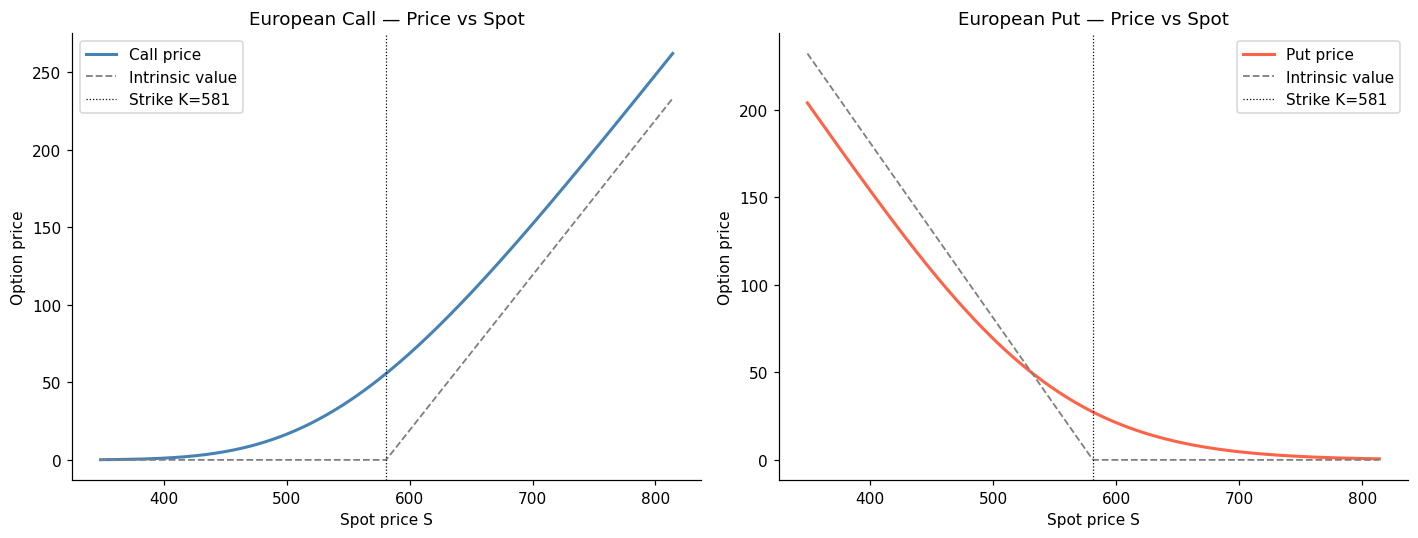

In [4]:
# Option Price as a Function of Spot Price
spot_range = np.linspace(S0 * 0.6, S0 * 1.4, 300)

call_prices = [black_scholes(s, K, T, r_f, sigma, "call")[0] for s in spot_range]
put_prices  = [black_scholes(s, K, T, r_f, sigma, "put")[0]  for s in spot_range]

# Intrinsic value (payoff at expiry if exercised immediately)
call_intrinsic = np.maximum(spot_range - K, 0)
put_intrinsic  = np.maximum(K - spot_range, 0)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, price, intrinsic, label, color in zip(
    axes,
    [call_prices, put_prices],
    [call_intrinsic, put_intrinsic],
    ["Call", "Put"],
    ["steelblue", "tomato"]
):
    ax.plot(spot_range, price, color=color, linewidth=2, label=f"{label} price")
    ax.plot(spot_range, intrinsic, color="gray", linewidth=1.2,
            linestyle="--", label="Intrinsic value")
    ax.axvline(K, color="black", linewidth=0.8, linestyle=":", label=f"Strike K={K}")
    ax.set_title(f"European {label} — Price vs Spot")
    ax.set_xlabel("Spot price S")
    ax.set_ylabel("Option price")
    ax.legend()

plt.tight_layout()
plt.show()

In [5]:
# Compute the Option Greeks
def compute_greeks(S, K, T, r, sigma, option_type="call"):
    """
    Compute the first-order Black-Scholes Greeks.

    Returns delta, gamma, vega, theta, rho.
    """
    _, d1, d2 = black_scholes(S, K, T, r, sigma, option_type)

    # Delta: sensitivity of price to spot
    if option_type == "call":
        delta = norm.cdf(d1)
    else:
        delta = norm.cdf(d1) - 1

    # Gamma: rate of change of delta (same for call and put)
    gamma = norm.pdf(d1) / (S * sigma * np.sqrt(T))

    # Vega: sensitivity to volatility (same for call and put), scaled to 1% move
    vega = S * norm.pdf(d1) * np.sqrt(T) / 100

    # Theta: time decay per calendar day
    if option_type == "call":
        theta = (-(S * norm.pdf(d1) * sigma) / (2 * np.sqrt(T))
                 - r * K * np.exp(-r * T) * norm.cdf(d2)) / 365
    else:
        theta = (-(S * norm.pdf(d1) * sigma) / (2 * np.sqrt(T))
                 + r * K * np.exp(-r * T) * norm.cdf(-d2)) / 365

    # Rho: sensitivity to risk-free rate, scaled to 1% move
    if option_type == "call":
        rho = K * T * np.exp(-r * T) * norm.cdf(d2) / 100
    else:
        rho = -K * T * np.exp(-r * T) * norm.cdf(-d2) / 100

    return {"delta": delta, "gamma": gamma, "vega": vega, "theta": theta, "rho": rho}

call_greeks = compute_greeks(S0, K, T, r_f, sigma, "call")
put_greeks  = compute_greeks(S0, K, T, r_f, sigma, "put")

print(f"{'Greek':<10} {'Call':>12} {'Put':>12}")
print("-" * 36)
for g in ["delta", "gamma", "vega", "theta", "rho"]:
    print(f"{g:<10} {call_greeks[g]:>12.4f} {put_greeks[g]:>12.4f}")

Greek              Call          Put
------------------------------------
delta            0.6462      -0.3538
gamma            0.0036       0.0036
vega             2.1619       2.1619
theta           -0.0962      -0.0205
rho              3.1974      -2.3292


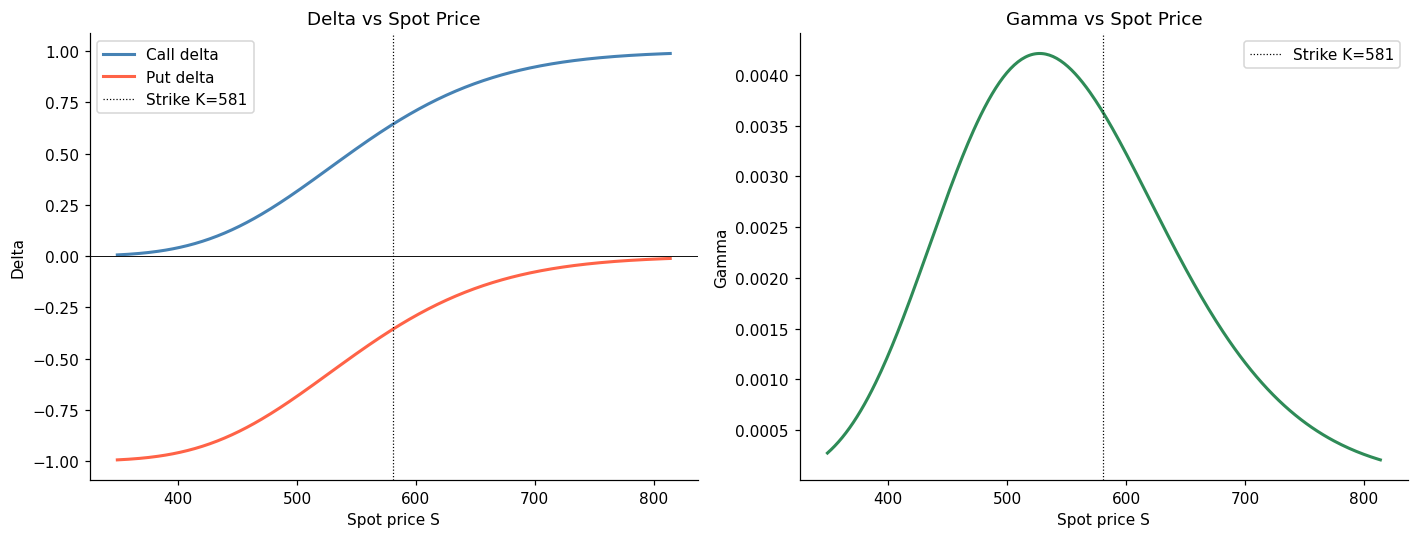

In [6]:
# Delta and Gamma Across Spot Prices
deltas_call = [compute_greeks(s, K, T, r_f, sigma, "call")["delta"] for s in spot_range]
deltas_put  = [compute_greeks(s, K, T, r_f, sigma, "put")["delta"]  for s in spot_range]
gammas      = [compute_greeks(s, K, T, r_f, sigma, "call")["gamma"] for s in spot_range]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Delta
axes[0].plot(spot_range, deltas_call, color="steelblue", linewidth=2, label="Call delta")
axes[0].plot(spot_range, deltas_put,  color="tomato",    linewidth=2, label="Put delta")
axes[0].axvline(K, color="black", linewidth=0.8, linestyle=":", label=f"Strike K={K}")
axes[0].axhline(0, color="black", linewidth=0.6)
axes[0].set_title("Delta vs Spot Price")
axes[0].set_xlabel("Spot price S")
axes[0].set_ylabel("Delta")
axes[0].legend()

# Gamma
axes[1].plot(spot_range, gammas, color="seagreen", linewidth=2)
axes[1].axvline(K, color="black", linewidth=0.8, linestyle=":", label=f"Strike K={K}")
axes[1].set_title("Gamma vs Spot Price")
axes[1].set_xlabel("Spot price S")
axes[1].set_ylabel("Gamma")
axes[1].legend()

plt.tight_layout()
plt.show()

In [7]:
# Plain Monte Carlo Option Pricing
def mc_price_plain(S0, K, T, r, sigma, n_paths, option_type="call", seed=42):
    """
    Price a European option via plain Monte Carlo under the risk-neutral measure.

    The asset evolves as:
        S_T = S0 * exp((r - 0.5*sigma^2)*T + sigma*sqrt(T)*Z),  Z ~ N(0,1)
    The price is the discounted expected payoff.
    """
    rng = np.random.default_rng(seed)
    Z   = rng.standard_normal(n_paths)

    # Simulate terminal price under risk-neutral measure (drift = r, not mu)
    S_T = S0 * np.exp((r - 0.5 * sigma**2) * T + sigma * np.sqrt(T) * Z)

    if option_type == "call":
        payoffs = np.maximum(S_T - K, 0)
    else:
        payoffs = np.maximum(K - S_T, 0)

    # Discount expected payoff back to present value
    price     = np.exp(-r * T) * payoffs.mean()
    std_error = np.exp(-r * T) * payoffs.std(ddof=1) / np.sqrt(n_paths)

    return price, std_error

N_PATHS = 100_000
mc_call, mc_call_se = mc_price_plain(S0, K, T, r_f, sigma, N_PATHS, "call")
mc_put,  mc_put_se  = mc_price_plain(S0, K, T, r_f, sigma, N_PATHS, "put")

print(f"Plain Monte Carlo  (n={N_PATHS:,} paths)")
print(f"  Call : {mc_call:.4f}  ±{1.96*mc_call_se:.4f}  |  BS: {bs_call:.4f}  |  error: {mc_call-bs_call:+.4f}")
print(f"  Put  : {mc_put:.4f}  ±{1.96*mc_put_se:.4f}  |  BS: {bs_put:.4f}  |  error: {mc_put-bs_put:+.4f}")

Plain Monte Carlo  (n=100,000 paths)
  Call : 55.7682  ±0.4725  |  BS: 55.9364  |  error: -0.1682
  Put  : 27.4033  ±0.2739  |  BS: 27.2081  |  error: +0.1952


In [8]:
# Variance Reduction I: Antithetic Variates
def mc_price_antithetic(S0, K, T, r, sigma, n_paths, option_type="call", seed=42):
    """
    Price a European option using antithetic variates.

    For every random draw Z, we also use -Z. The two resulting payoffs are
    negatively correlated, so averaging them reduces variance without bias.
    n_paths must be even; we simulate n_paths/2 pairs.
    """
    rng    = np.random.default_rng(seed)
    half_n = n_paths // 2
    Z      = rng.standard_normal(half_n)

    # Simulate terminal prices for Z and its antithetic counterpart -Z
    S_T_pos = S0 * np.exp((r - 0.5 * sigma**2) * T + sigma * np.sqrt(T) *  Z)
    S_T_neg = S0 * np.exp((r - 0.5 * sigma**2) * T + sigma * np.sqrt(T) * -Z)

    if option_type == "call":
        payoffs_pos = np.maximum(S_T_pos - K, 0)
        payoffs_neg = np.maximum(S_T_neg - K, 0)
    else:
        payoffs_pos = np.maximum(K - S_T_pos, 0)
        payoffs_neg = np.maximum(K - S_T_neg, 0)

    # Average each antithetic pair before taking the grand mean
    paired_payoffs = (payoffs_pos + payoffs_neg) / 2

    price     = np.exp(-r * T) * paired_payoffs.mean()
    std_error = np.exp(-r * T) * paired_payoffs.std(ddof=1) / np.sqrt(half_n)

    return price, std_error

av_call, av_call_se = mc_price_antithetic(S0, K, T, r_f, sigma, N_PATHS, "call")
av_put,  av_put_se  = mc_price_antithetic(S0, K, T, r_f, sigma, N_PATHS, "put")

print(f"Antithetic Variates  (n={N_PATHS:,} paths)")
print(f"  Call : {av_call:.4f}  ±{1.96*av_call_se:.4f}  |  BS: {bs_call:.4f}  |  error: {av_call-bs_call:+.4f}")
print(f"  Put  : {av_put:.4f}  ±{1.96*av_put_se:.4f}  |  BS: {bs_put:.4f}  |  error: {av_put-bs_put:+.4f}")

Antithetic Variates  (n=100,000 paths)
  Call : 56.0214  ±0.3223  |  BS: 55.9364  |  error: +0.0849
  Put  : 27.2452  ±0.2148  |  BS: 27.2081  |  error: +0.0370


In [9]:
# Variance Reduction II: Control Variates
def mc_price_control_variate(S0, K, T, r, sigma, n_paths, option_type="call", seed=42):
    """
    Price a European option using the control variate technique.

    We use the discounted terminal stock price as the control variate because
    its true expectation is known analytically: E[e^{-rT} * S_T] = S0.

    The corrected estimator is:
        price_cv = price_plain - beta * (control_mean - S0)
    where beta is estimated by OLS regression of payoffs on the control.
    """
    rng = np.random.default_rng(seed)
    Z   = rng.standard_normal(n_paths)

    S_T = S0 * np.exp((r - 0.5 * sigma**2) * T + sigma * np.sqrt(T) * Z)

    if option_type == "call":
        payoffs = np.maximum(S_T - K, 0)
    else:
        payoffs = np.maximum(K - S_T, 0)

    # Control variate: discounted S_T, whose true mean is S0 (no-arbitrage)
    control       = np.exp(-r * T) * S_T
    control_mean  = control.mean()
    true_mean     = S0                # known analytically

    # Estimate optimal beta via OLS (covariance / variance of control)
    beta = np.cov(np.exp(-r * T) * payoffs, control)[0, 1] / np.var(control, ddof=1)

    # Apply correction
    price_plain = np.exp(-r * T) * payoffs.mean()
    price_cv    = price_plain - beta * (control_mean - true_mean)
    std_error   = np.exp(-r * T) * payoffs.std(ddof=1) / np.sqrt(n_paths)

    return price_cv, std_error, beta

cv_call, cv_call_se, beta_c = mc_price_control_variate(S0, K, T, r_f, sigma, N_PATHS, "call")
cv_put,  cv_put_se,  beta_p = mc_price_control_variate(S0, K, T, r_f, sigma, N_PATHS, "put")

print(f"Control Variates  (n={N_PATHS:,} paths)")
print(f"  Call : {cv_call:.4f}  ±{1.96*cv_call_se:.4f}  |  BS: {bs_call:.4f}  |  error: {cv_call-bs_call:+.4f}  |  β={beta_c:.4f}")
print(f"  Put  : {cv_put:.4f}  ±{1.96*cv_put_se:.4f}  |  BS: {bs_put:.4f}  |  error: {cv_put-bs_put:+.4f}  |  β={beta_p:.4f}")

Control Variates  (n=100,000 paths)
  Call : 56.0147  ±0.4725  |  BS: 55.9364  |  error: +0.0783  |  β=0.6784
  Put  : 27.2864  ±0.2739  |  BS: 27.2081  |  error: +0.0783  |  β=-0.3216


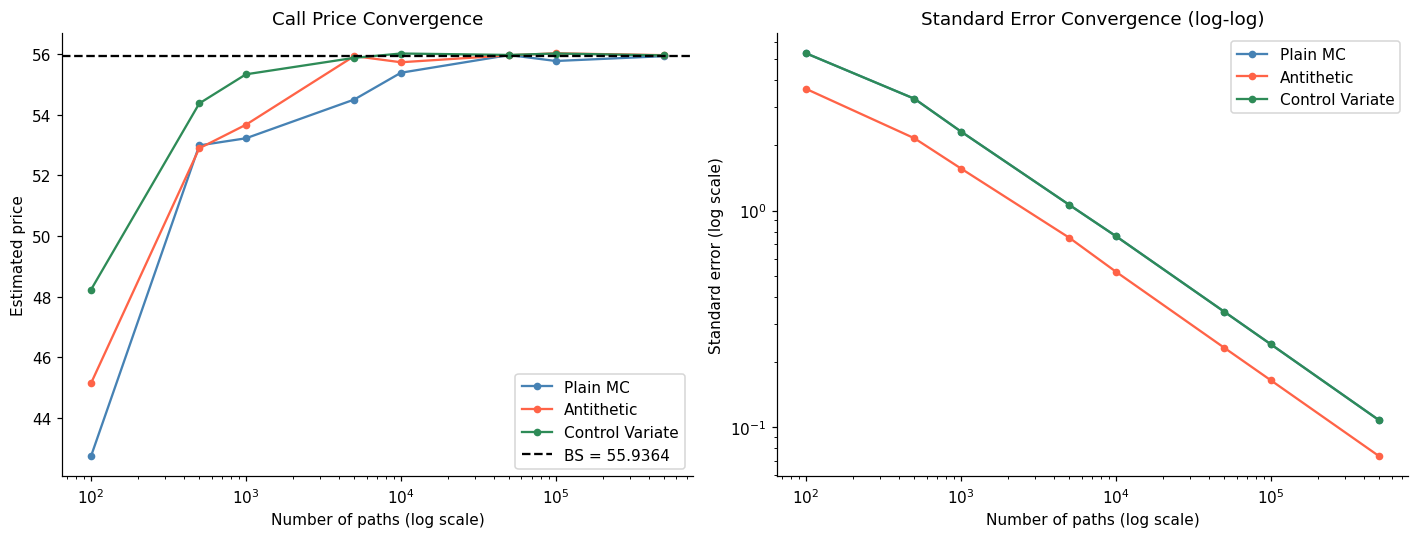

In [10]:
# Convergence of All Three Estimators
# Show how each method's price estimate converges to the BS benchmark
# as the number of paths increases

path_counts = [100, 500, 1_000, 5_000, 10_000, 50_000, 100_000, 500_000]

results = {"plain": [], "antithetic": [], "control": []}
se_results = {"plain": [], "antithetic": [], "control": []}

for n in path_counts:
    p,  se_p  = mc_price_plain(S0, K, T, r_f, sigma, n, "call", seed=42)
    a,  se_a  = mc_price_antithetic(S0, K, T, r_f, sigma, n, "call", seed=42)
    c,  se_c, _ = mc_price_control_variate(S0, K, T, r_f, sigma, n, "call", seed=42)

    results["plain"].append(p)
    results["antithetic"].append(a)
    results["control"].append(c)
    se_results["plain"].append(se_p)
    se_results["antithetic"].append(se_a)
    se_results["control"].append(se_c)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

colors = {"plain": "steelblue", "antithetic": "tomato", "control": "seagreen"}
labels = {"plain": "Plain MC", "antithetic": "Antithetic", "control": "Control Variate"}

# Price convergence
for method in results:
    axes[0].plot(path_counts, results[method], marker="o", markersize=4,
                 color=colors[method], label=labels[method])
axes[0].axhline(bs_call, color="black", linestyle="--", linewidth=1.5, label=f"BS = {bs_call:.4f}")
axes[0].set_xscale("log")
axes[0].set_title("Call Price Convergence")
axes[0].set_xlabel("Number of paths (log scale)")
axes[0].set_ylabel("Estimated price")
axes[0].legend()

# Standard error convergence
for method in se_results:
    axes[1].plot(path_counts, se_results[method], marker="o", markersize=4,
                 color=colors[method], label=labels[method])
axes[1].set_xscale("log")
axes[1].set_yscale("log")
axes[1].set_title("Standard Error Convergence (log-log)")
axes[1].set_xlabel("Number of paths (log scale)")
axes[1].set_ylabel("Standard error (log scale)")
axes[1].legend()

plt.tight_layout()
plt.show()

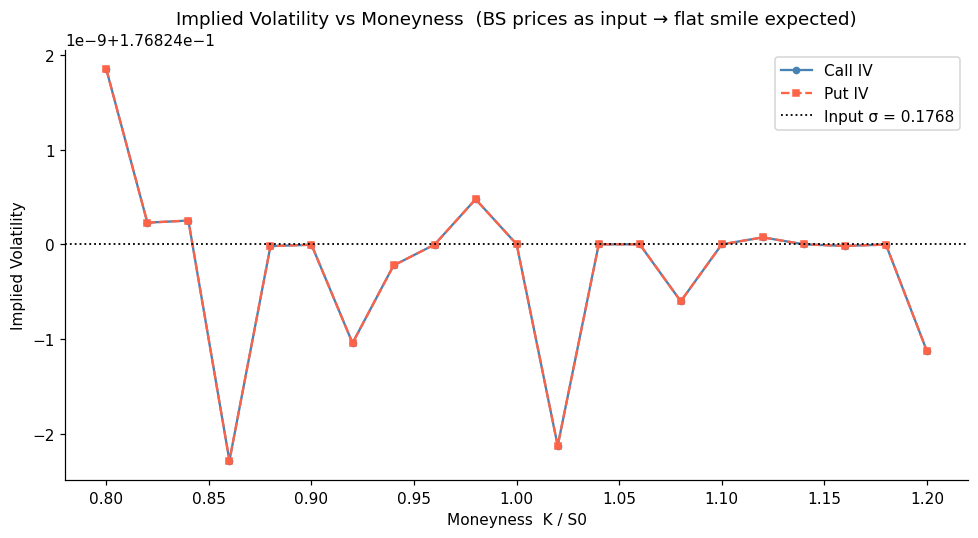

Note: because we use BS-generated prices as input, the IV is flat by
construction. With real market prices, this plot would show the well-known
volatility smile or skew — another empirical departure from GBM.


In [11]:
# Implied Volatility
from scipy.optimize import brentq

def implied_volatility(market_price, S, K, T, r, option_type="call",
                       tol=1e-8, max_iter=200):
    """
    Recover the implied volatility from a market option price by inverting
    the Black-Scholes formula numerically using Brent's root-finding method.
    """
    def objective(sigma):
        return black_scholes(S, K, T, r, sigma, option_type)[0] - market_price

    try:
        iv = brentq(objective, 1e-6, 10.0, xtol=tol, maxiter=max_iter)
    except ValueError:
        iv = np.nan   # price is outside the BS range

    return iv

# Compute IV across a range of strikes (the volatility smile / skew)
moneyness  = np.linspace(0.80, 1.20, 21)   # K/S0 ratios
strikes    = moneyness * S0

iv_calls = []
iv_puts  = []

for strike in strikes:
    # Use the BS model itself as the "market" — IV should recover sigma exactly
    # In practice you would replace bs_price with actual market quotes
    bs_c = black_scholes(S0, strike, T, r_f, sigma, "call")[0]
    bs_p = black_scholes(S0, strike, T, r_f, sigma, "put")[0]
    iv_calls.append(implied_volatility(bs_c, S0, strike, T, r_f, "call"))
    iv_puts.append(implied_volatility(bs_p, S0, strike, T, r_f, "put"))

plt.figure(figsize=(9, 5))
plt.plot(moneyness, iv_calls, color="steelblue", marker="o", markersize=4, label="Call IV")
plt.plot(moneyness, iv_puts,  color="tomato",    marker="s", markersize=4,
         linestyle="--", label="Put IV")
plt.axhline(sigma, color="black", linestyle=":", linewidth=1.2, label=f"Input σ = {sigma:.4f}")
plt.title("Implied Volatility vs Moneyness  (BS prices as input → flat smile expected)")
plt.xlabel("Moneyness  K / S0")
plt.ylabel("Implied Volatility")
plt.legend()
plt.tight_layout()
plt.show()

print("Note: because we use BS-generated prices as input, the IV is flat by")
print("construction. With real market prices, this plot would show the well-known")
print("volatility smile or skew — another empirical departure from GBM.")

In [12]:
# Pricing Summary
summary = pd.DataFrame({
    "Method": [
        "Black-Scholes (analytical)",
        "Plain Monte Carlo",
        "Antithetic Variates",
        "Control Variate",
    ],
    "Call Price": [
        round(bs_call, 4),
        round(mc_call, 4),
        round(av_call, 4),
        round(cv_call, 4),
    ],
    "Call ±95% CI": [
        "—",
        f"±{1.96*mc_call_se:.4f}",
        f"±{1.96*av_call_se:.4f}",
        f"±{1.96*cv_call_se:.4f}",
    ],
    "Put Price": [
        round(bs_put, 4),
        round(mc_put, 4),
        round(av_put, 4),
        round(cv_put, 4),
    ],
    "Put ±95% CI": [
        "—",
        f"±{1.96*mc_put_se:.4f}",
        f"±{1.96*av_put_se:.4f}",
        f"±{1.96*cv_put_se:.4f}",
    ],
})

print("=" * 80)
print(f"  Option Pricing Summary  —  {ticker}  |  S0={S0:.2f}, K={K}, T={T}yr, r={r_f}, σ={sigma:.4f}")
print("=" * 80)
print(summary.to_string(index=False))
print("=" * 80)
print()
print("The estimated sigma from Notebook 02 and the delta computed here")
print("will be passed directly into the hedging simulation in Notebook 04.")

# Save pricing results for Notebook 04
pricing_output = {
    "bs_call": round(bs_call, 6),
    "bs_put":  round(bs_put, 6),
    "delta_call": round(compute_greeks(S0, K, T, r_f, sigma, "call")["delta"], 6),
    "delta_put":  round(compute_greeks(S0, K, T, r_f, sigma, "put")["delta"], 6),
    "K":   K,
    "T":   T,
    "r_f": r_f,
}
with open("pricing_output.json", "w") as f:
    json.dump(pricing_output, f, indent=2)
print("Pricing results saved to pricing_output.json")

  Option Pricing Summary  —  SPY  |  S0=581.39, K=581, T=1.0yr, r=0.05, σ=0.1768
                    Method  Call Price Call ±95% CI  Put Price Put ±95% CI
Black-Scholes (analytical)     55.9364            —    27.2081           —
         Plain Monte Carlo     55.7682      ±0.4725    27.4033     ±0.2739
       Antithetic Variates     56.0214      ±0.3223    27.2452     ±0.2148
           Control Variate     56.0147      ±0.4725    27.2864     ±0.2739

The estimated sigma from Notebook 02 and the delta computed here
will be passed directly into the hedging simulation in Notebook 04.
Pricing results saved to pricing_output.json
